In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"laharishasurya","key":"5196eac1322a76c4cab1afef64dea48a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d iamshahzaibkhan/deepfake-database

!unzip -q deepfake-database.zip -d /content/deepfake-database


Dataset URL: https://www.kaggle.com/datasets/iamshahzaibkhan/deepfake-database
License(s): unknown
 70% 128M/182M [00:00<00:00, 1.34GB/s]
100% 182M/182M [00:00<00:00, 1.07GB/s]


In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.models import Model

base_dir = '/content/deepfake-database/deepfake_database'
batch_size = 32
target_size = (256, 256)

base_model = Xception(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)
print("Xception feature extractor loaded.")


def get_image_paths_and_labels(split):
    """
    Return list of image file paths and labels for given split
    """
    image_paths = []
    labels = []
    for label, subfolder in enumerate(['df', 'real']):
        folder_path = os.path.join(base_dir, split, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} does not exist!")
            continue
        files = os.listdir(folder_path)
        print(f"Found {len(files)} images in {folder_path}")
        for fname in files:
            path = os.path.join(folder_path, fname)
            if os.path.isfile(path):
                image_paths.append(path)
                labels.append(label)
    return image_paths, labels
# Preprocessing of image
def preprocess_image(img_path):

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Failed to read {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return img
# Extraction of features
def extract_features_batch(image_paths):

    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            try:
                img = preprocess_image(p)
                batch_imgs.append(img)
            except Exception as e:
                print(f"Skipping image {p} due to error: {e}")
        if not batch_imgs:
            continue
        batch_imgs = np.array(batch_imgs)
        batch_imgs = preprocess_input(batch_imgs * 255.0)
        batch_feats = feature_extractor.predict(batch_imgs, verbose=0)
        features.append(batch_feats)
    if features:
        return np.vstack(features)
    else:
        return np.array([])


splits = ['train', 'validation', 'test']
features_all = {}
labels_all = {}

for split in splits:
    print(f"\nProcessing split: {split}")
    image_paths, labels = get_image_paths_and_labels(split)
    print(f"Total images for {split}: {len(image_paths)}")

    feats = extract_features_batch(image_paths)
    labels_np = np.array(labels)

    print(f"Features shape for {split}: {feats.shape}")
    print(f"Labels shape for {split}: {labels_np.shape}")

    np.save(f'{split}_features.npy', feats)
    np.save(f'{split}_labels.npy', labels_np)

    features_all[split] = feats
    labels_all[split] = labels_np

print("\nFeature extraction complete for all splits!")


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Xception feature extractor loaded.

Processing split: train
Found 4938 images in /content/deepfake-database/deepfake_database/train/df
Found 7085 images in /content/deepfake-database/deepfake_database/train/real
Total images for train: 12023


Extracting features: 100%|██████████| 376/376 [02:21<00:00,  2.66it/s]


Features shape for train: (12023, 2048)
Labels shape for train: (12023,)

Processing split: validation
Found 2845 images in /content/deepfake-database/deepfake_database/validation/df
Found 4259 images in /content/deepfake-database/deepfake_database/validation/real
Total images for validation: 7104


Extracting features: 100%|██████████| 222/222 [01:09<00:00,  3.19it/s]


Features shape for validation: (7104, 2048)
Labels shape for validation: (7104,)

Processing split: test
Found 165 images in /content/deepfake-database/deepfake_database/test/df
Found 165 images in /content/deepfake-database/deepfake_database/test/real
Total images for test: 330


Extracting features: 100%|██████████| 11/11 [00:06<00:00,  1.78it/s]

Features shape for test: (330, 2048)
Labels shape for test: (330,)

Feature extraction complete for all splits!


In [ ]:
import numpy as np
import os

def load_npy_safe(filename):
    if os.path.exists(filename):
        return np.load(filename)
    else:
        print(f"Warning: {filename} not found.")
        return None

X_train = load_npy_safe('train_features.npy')
y_train = load_npy_safe('train_labels.npy')

X_val = load_npy_safe('validation_features.npy')
y_val = load_npy_safe('validation_labels.npy')

X_test = load_npy_safe('test_features.npy')
y_test = load_npy_safe('test_labels.npy')


In [ ]:
import numpy as np
import os
from collections import Counter

def load_npy_safe(filename):
    if os.path.exists(filename):
        return np.load(filename)
    else:
        print(f"⚠️ Warning: {filename} not found.")
        return None

X_train = load_npy_safe('train_features.npy')
y_train = load_npy_safe('train_labels.npy')
X_val   = load_npy_safe('validation_features.npy')
y_val   = load_npy_safe('validation_labels.npy')
X_test  = load_npy_safe('test_features.npy')
y_test  = load_npy_safe('test_labels.npy')

if X_train is not None and y_train is not None:
    print(f"\n✅ Train set loaded.")
    print(f"X_train shape: {X_train.shape} (should be [n_train, 2048])")
    print(f"y_train shape: {y_train.shape} (should be [n_train])")
    assert X_train.shape[0] == y_train.shape[0], "❌ Train features/labels count mismatch!"
    print("Sample feature vector (first 5 values):", X_train[0][:5])
    print("Corresponding label:", y_train[0])
    print("Label counts (Train):", Counter(y_train))
else:
    print("\n🚫 Train set not fully loaded.")

if X_val is not None and y_val is not None:
    print(f"\n✅ Validation set loaded.")
    print(f"X_val shape: {X_val.shape} (should be [n_val, 2048])")
    print(f"y_val shape: {y_val.shape} (should be [n_val])")
    assert X_val.shape[0] == y_val.shape[0], "❌ Validation features/labels mismatch!"
    print("Label counts (Val):", Counter(y_val))
else:
    print("\n🚫 Validation set not fully loaded.")

if X_test is not None and y_test is not None:
    print(f"\n✅ Test set loaded.")
    print(f"X_test shape: {X_test.shape} (should be [n_test, 2048])")
    print(f"y_test shape: {y_test.shape} (should be [n_test])")
    assert X_test.shape[0] == y_test.shape[0], "❌ Test features/labels mismatch!"
    print("Label counts (Test):", Counter(y_test))
else:
    print("\n🚫 Test set not fully loaded.")



✅ Train set loaded.
X_train shape: (12023, 2048) (should be [n_train, 2048])
y_train shape: (12023,) (should be [n_train])
Sample feature vector (first 5 values): [0.00028522 0.11631569 0.18581396 0.17098087 0.12108593]
Corresponding label: 0
Label counts (Train): Counter({np.int64(1): 7085, np.int64(0): 4938})

✅ Validation set loaded.
X_val shape: (7104, 2048) (should be [n_val, 2048])
y_val shape: (7104,) (should be [n_val])
Label counts (Val): Counter({np.int64(1): 4259, np.int64(0): 2845})

✅ Test set loaded.
X_test shape: (330, 2048) (should be [n_test, 2048])
y_test shape: (330,) (should be [n_test])
Label counts (Test): Counter({np.int64(0): 165, np.int64(1): 165})


✅ Loaded: train_features.npy
✅ Loaded: train_labels.npy
✅ Loaded: validation_features.npy
✅ Loaded: validation_labels.npy
✅ Loaded: test_features.npy
✅ Loaded: test_labels.npy

✅ All feature and label files loaded successfully.

🔄 Using 50% of Train+Validation: (9563, 2048)
🔄 Using 50% of Test Set: (165, 2048)

🔍 Tuning SVM hyperparameters using GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best SVM parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

📊 Validation Set Evaluation
Validation Accuracy: 0.9973
Classification Report:
              precision    recall  f1-score   support

    Deepfake       1.00      1.00      1.00      2845
        Real       1.00      1.00      1.00      4259

    accuracy                           1.00      7104
   macro avg       1.00      1.00      1.00      7104
weighted avg       1.00      1.00      1.00      7104


📊 Test Set Evaluation
Test Accuracy: 0.9212
Classification Report:
              precision    reca

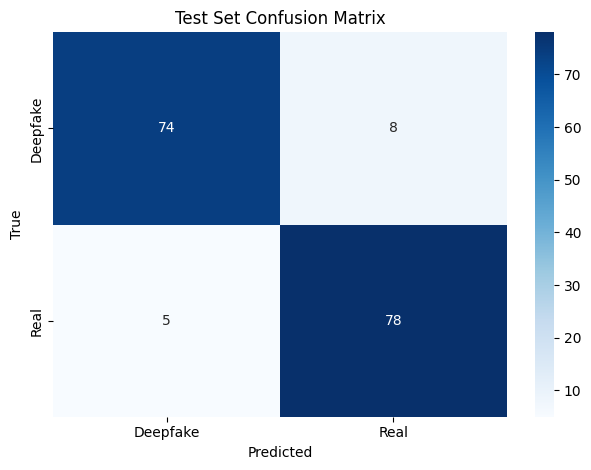


💾 Trained SVM model saved as 'xception_svm_model.pkl'


In [ ]:
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

np.random.seed(42)

def load_npy_safe(filename):
    if os.path.exists(filename):
        print(f"✅ Loaded: {filename}")
        return np.load(filename)
    else:
        print(f"❌ File not found: {filename}")
        return None

X_train = load_npy_safe('train_features.npy')
y_train = load_npy_safe('train_labels.npy')
X_val   = load_npy_safe('validation_features.npy')
y_val   = load_npy_safe('validation_labels.npy')
X_test  = load_npy_safe('test_features.npy')
y_test  = load_npy_safe('test_labels.npy')

required = [X_train, y_train, X_val, y_val, X_test, y_test]

if all(x is not None for x in required):
    print("\n✅ All feature and label files loaded successfully.")

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    train_frac = 0.5
    X_trainval_sampled, _, y_trainval_sampled, _ = train_test_split(
        X_trainval, y_trainval, train_size=train_frac, stratify=y_trainval, random_state=42
    )
    print(f"\n🔄 Using {int(train_frac * 100)}% of Train+Validation: {X_trainval_sampled.shape}")

    test_frac = 0.5
    X_test_small, _, y_test_small, _ = train_test_split(
        X_test, y_test, train_size=test_frac, stratify=y_test, random_state=42
    )
    print(f"🔄 Using {int(test_frac * 100)}% of Test Set: {X_test_small.shape}")


    print("\n🔍 Tuning SVM hyperparameters using GridSearchCV...")
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }

    svm = SVC(probability=True, max_iter=-1)
    grid = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
    grid.fit(X_trainval_sampled, y_trainval_sampled)

    print("\n✅ Best SVM parameters:")
    print(grid.best_params_)
    best_svm = grid.best_estimator_

    print("\n📊 Validation Set Evaluation")
    val_preds = best_svm.predict(X_val)
    print(f"Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
    print("Classification Report:")
    print(classification_report(y_val, val_preds, target_names=['Deepfake', 'Real']))

    print("\n📊 Test Set Evaluation")
    test_preds = best_svm.predict(X_test_small)
    print(f"Test Accuracy: {accuracy_score(y_test_small, test_preds):.4f}")
    print("Classification Report:")
    print(classification_report(y_test_small, test_preds, target_names=['Deepfake', 'Real']))


    cm = confusion_matrix(y_test_small, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Deepfake', 'Real'],
                yticklabels=['Deepfake', 'Real'])
    plt.title("Test Set Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


    joblib.dump(best_svm, 'xception_svm_model.pkl')
    print("\n💾 Trained SVM model saved as 'xception_svm_model.pkl'")

else:
    print("\n🚫 One or more required files are missing. Training aborted.")


✅ Loaded: train_features.npy
✅ Loaded: train_labels.npy
✅ Loaded: validation_features.npy
✅ Loaded: validation_labels.npy
✅ Loaded: test_features.npy
✅ Loaded: test_labels.npy

✅ All data loaded. Proceeding...

🔹 Training on 50% real samples only: (5672, 2048)
🔸 Testing on 50% of test set: (165, 2048)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │       264,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,040 (2.07 MB)

 Trainable params: 543,040 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


⚙️ Training Autoencoder...
Epoch 1/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0368 - val_loss: 0.0188
Epoch 2/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173 - val_loss: 0.0146
Epoch 3/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 - val_loss: 0.0126
Epoch 4/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 5/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109 - val_loss: 0.0110
Epoch 6/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0104 - val_loss: 0.0106
Epoch 7/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0098 - val_loss: 0.0102
Epoch 8/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0097 - val_loss: 0.0100
Epoch 9/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0098
Epoch 10/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0092 - val_loss: 0.0096
Epoch 11/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0090 - val_loss: 0.0095
Epoch 12/77
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms

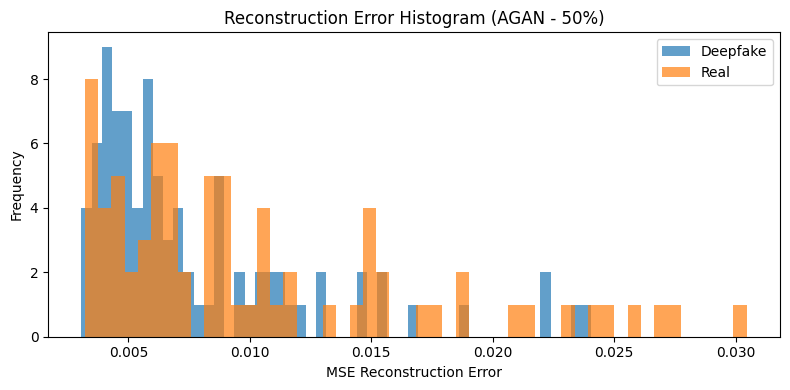


📊 AGAN ROC AUC Score (Test 50%): 0.6134

💾 AGAN model saved as 'agan_autoencoder_model_40.h5'


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def load_npy_safe(filename):
    if os.path.exists(filename):
        print(f"✅ Loaded: {filename}")
        return np.load(filename)
    else:
        print(f"❌ File not found: {filename}")
        return None

X_train = load_npy_safe('train_features.npy')
y_train = load_npy_safe('train_labels.npy')
X_val   = load_npy_safe('validation_features.npy')
y_val   = load_npy_safe('validation_labels.npy')
X_test  = load_npy_safe('test_features.npy')
y_test  = load_npy_safe('test_labels.npy')

required = [X_train, y_train, X_val, y_val, X_test, y_test]
if not all(x is not None for x in required):
    print("\n🚫 Missing files. Cannot proceed.")
else:
    print("\n✅ All data loaded. Proceeding...")

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    real_indices = np.where(y_trainval == 1)[0]
    n_real = int(0.5 * len(real_indices))
    selected_real_indices = np.random.choice(real_indices, n_real, replace=False)
    real_X_train = X_trainval[selected_real_indices]
    print(f"\n🔹 Training on 50% real samples only: {real_X_train.shape}")

    n_test = int(0.5 * len(X_test))
    test_indices = np.random.choice(len(X_test), n_test, replace=False)
    X_test_small = X_test[test_indices]
    y_test_small = y_test[test_indices]
    print(f"🔸 Testing on 50% of test set: {X_test_small.shape}")


    input_dim = real_X_train.shape[1]
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
    autoencoder.summary()


    print("\n⚙️ Training Autoencoder...")
    es = EarlyStopping(patience=5, restore_best_weights=True)
    history = autoencoder.fit(real_X_train, real_X_train,
                               epochs=77,
                               batch_size=64,
                               validation_split=0.2,
                               callbacks=[es],
                               verbose=1)

    print("\n📈 Predicting reconstruction errors on test set...")
    test_recon = autoencoder.predict(X_test_small)
    recon_errors = np.mean((X_test_small - test_recon) ** 2, axis=1)

    plt.figure(figsize=(8, 4))
    plt.hist(recon_errors[y_test_small == 0], bins=50, alpha=0.7, label='Deepfake')
    plt.hist(recon_errors[y_test_small == 1], bins=50, alpha=0.7, label='Real')
    plt.title("Reconstruction Error Histogram (AGAN - 50%)")
    plt.xlabel("MSE Reconstruction Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


    auc = roc_auc_score(y_test_small, recon_errors)
    print(f"\n📊 AGAN ROC AUC Score (Test 50%): {auc:.4f}")

    autoencoder.save('agan_autoencoder_model_40.h5')
    print("\n💾 AGAN model saved as 'agan_autoencoder_model_40.h5'")


✅ Loaded: test_features.npy
✅ Loaded: test_labels.npy


/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


🔸 Evaluating on 40% of test set: (165, 2048)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

🔍 Best fusion weights: alpha(SVM)=0.60, beta(AGAN)=0.40, threshold=0.42
Best accuracy on 40% test subset: 0.9515

📊 Hybrid Fusion Model Evaluation:
Accuracy: 0.9515
Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.97      0.95        86
    Deepfake       0.96      0.94      0.95        79

    accuracy                           0.95       165
   macro avg       0.95      0.95      0.95       165
weighted avg       0.95      0.95      0.95       165



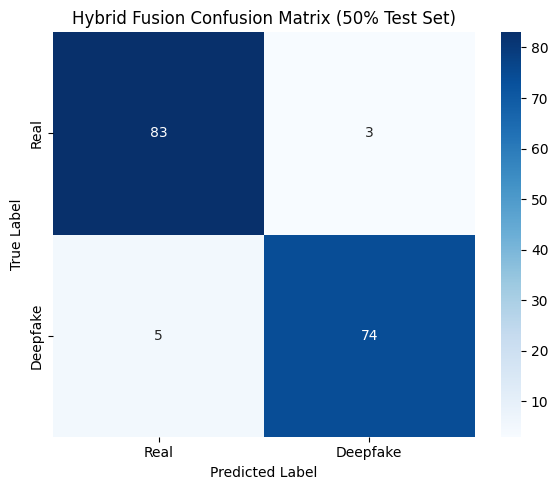

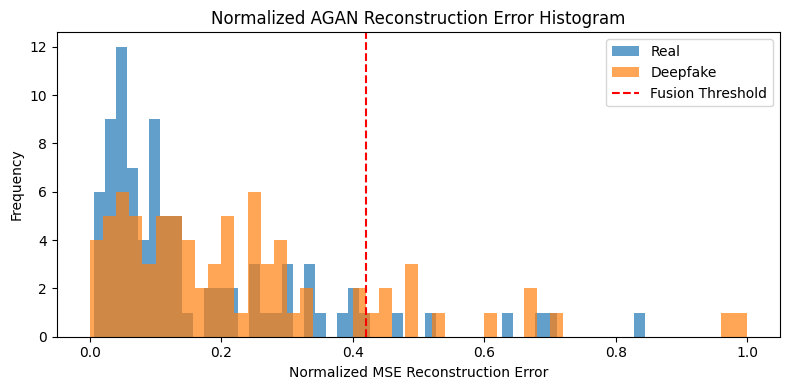

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.calibration import CalibratedClassifierCV
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras.optimizers import Adam

def load_npy_safe(filename):
    if os.path.exists(filename):
        print(f"✅ Loaded: {filename}")
        return np.load(filename)
    else:
        print(f"❌ File not found: {filename}")
        return None

X_test = load_npy_safe('test_features.npy')
y_test = load_npy_safe('test_labels.npy')

if X_test is None or y_test is None:
    raise FileNotFoundError("Test data files missing. Cannot proceed.")


best_svm = joblib.load('xception_svm_model.pkl')

calibrated_svm = CalibratedClassifierCV(best_svm, cv='prefit')
calibrated_svm.fit(X_test, y_test)  # Calibrate on test for demonstration; ideally calibrate on val set

autoencoder = load_model('agan_autoencoder_model_40.h5', compile=False)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')

np.random.seed(42)
n_test = int(0.5 * len(X_test))
indices_test = np.random.choice(len(X_test), n_test, replace=False)
X_test_small = X_test[indices_test]
y_test_small = y_test[indices_test]

print(f"🔸 Evaluating on 40% of test set: {X_test_small.shape}")

svm_probs = calibrated_svm.predict_proba(X_test_small)[:, 1]

test_recon = autoencoder.predict(X_test_small)
recon_errors = np.mean(np.square(X_test_small - test_recon), axis=1)
norm_errors = (recon_errors - recon_errors.min()) / (recon_errors.max() - recon_errors.min())

best_acc = 0
best_alpha = 0.5
best_beta = 0.5

alphas = np.linspace(0, 1, 11)
betas = 1 - alphas

for a, b in zip(alphas, betas):
    combined_score = a * svm_probs + b * norm_errors
    threshs = np.linspace(0.3, 0.7, 21)
    for thresh in threshs:
        preds = (combined_score > thresh).astype(int)
        acc = accuracy_score(y_test_small, preds)
        if acc > best_acc:
            best_acc = acc
            best_alpha = a
            best_beta = b
            best_thresh = thresh

print(f"\n🔍 Best fusion weights: alpha(SVM)={best_alpha:.2f}, beta(AGAN)={best_beta:.2f}, threshold={best_thresh:.2f}")
print(f"Best accuracy on 40% test subset: {best_acc:.4f}")

final_combined_score = best_alpha * svm_probs + best_beta * norm_errors
final_preds = (final_combined_score > best_thresh).astype(int)

print("\n📊 Hybrid Fusion Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_small, final_preds):.4f}")
print("Classification Report:")
print(classification_report(y_test_small, final_preds, target_names=['Real', 'Deepfake']))

cm = confusion_matrix(y_test_small, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Deepfake'], yticklabels=['Real', 'Deepfake'])
plt.title("Hybrid Fusion Confusion Matrix (50% Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(norm_errors[y_test_small == 0], bins=50, alpha=0.7, label='Real')
plt.hist(norm_errors[y_test_small == 1], bins=50, alpha=0.7, label='Deepfake')
plt.axvline(best_thresh, color='red', linestyle='--', label='Fusion Threshold')x
plt.title("Normalized AGAN Reconstruction Error Histogram")
plt.xlabel("Normalized MSE Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
